#### 24th August 2026
## MLL LAB 5
##### Anirvin Iyer<br>240905318<br>CSE D- 32

### Exercise 1

Let’s say we have a fictional dataset of pairs of variables, a mother<br> and her daughter’s heights:

| Mother Height (X) | Daughter Height (Y) |
|---:|---:|
| 58 | 60 |
| 62 | 60 |
| 60 | 58 |
| 64 | 60 |
| 67 | 70 |
| 70 | 72 |

Create a CSV file for the above training data and write a Python function<br> program to find the fitted linear regression with gradient descent<br> technique.

Compare the coefficients obtained from the sklearn model with your program.

Compute the log loss, MSE and RMSE.

Plot the graph Daughter height (Y-axis) vs Mother height (X-axis) with blue colour.<br> Also, plot the line of best fit with red colour.

Predict her daughter’s height with given a new mother height as 63.

Plot the graph of error in y-axis and iteration in x-axis with 4 epochs<br> (6x4=24 iterations).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

In [ ]:

data = {
    "mother_height": [58, 62, 60, 64, 67, 70],
    "daughter_height": [60, 60, 58, 60, 70, 72]
}

df = pd.DataFrame(data)
df.to_csv("height_data.csv", index=False)

df = pd.read_csv("height_data.csv")

X = df["mother_height"].values
y = df["daughter_height"].values

print(df)

   mother_height  daughter_height
0             58               60
1             62               60
2             60               58
3             64               60
4             67               70
5             70               72


In [8]:
def gradient_descent(X, y, learning_rate=0.0001, epochs=4):
    w = 0.0
    b = 0.0
    errors = []
    iterations = []

    iteration = 0

    for epoch in range(epochs):
        for i in range(len(X)):

            y_pred = w * X[i] + b
            error = y_pred - y[i]

            dw = error * X[i]
            db = error

            w -= learning_rate * dw
            b -= learning_rate * db

            errors.append(error ** 2)
            iterations.append(iteration)
            iteration += 1

    return w, b, errors, iterations


w, b, errors, iterations = gradient_descent(X, y)

print("Gradient Descent:")
print("Coefficient (w):", w)
print("Intercept (b):", b)
print("Iterations:", len(iterations))

Gradient Descent:
Coefficient (w): 1.0149205396744159
Intercept (b): 0.016406249586034958
Iterations: 24


In [9]:
model = LinearRegression()
model.fit(X.reshape(-1, 1), y)

print("Our model:")
print("Coefficient:", w)
print("Intercept:", b)

print("\nSklearn:")
print("Coefficient:", model.coef_[0])
print("Intercept:", model.intercept_)


Our model:
Coefficient: 1.0149205396744159
Intercept: 0.016406249586034958

Sklearn:
Coefficient: 1.2060301507537687
Intercept: -13.249581239530976


In [10]:
y_pred = w * X + b

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print("Predictions:", y_pred)
print("MSE:", mse)
print("RMSE:", rmse)

Predictions: [58.88179755 62.94147971 60.91163863 64.97132079 68.01608241 71.06084403]
MSE: 7.985382074972457
RMSE: 2.8258418347410132


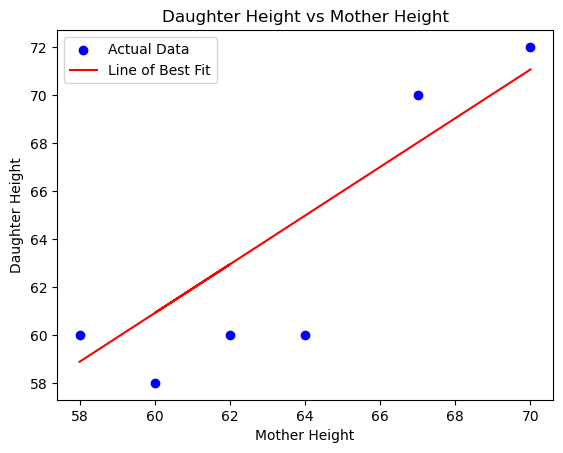

In [11]:
plt.scatter(X, y, color="blue", label="Actual Data")
plt.plot(X, y_pred, color="red", label="Line of Best Fit")

plt.xlabel("Mother Height")
plt.ylabel("Daughter Height")
plt.title("Daughter Height vs Mother Height")
plt.legend()
plt.show()

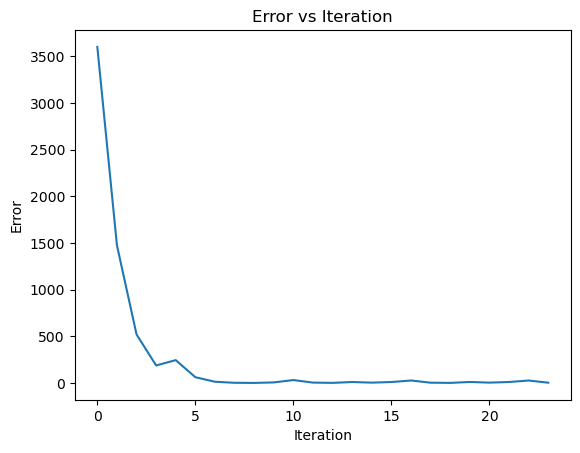

In [12]:
plt.plot(iterations, errors)

plt.xlabel("Iteration")
plt.ylabel("Error")
plt.title("Error vs Iteration")

plt.show()

### Exercise 2

Create a CSV file for the above training data and write a Python function program<br> to find the fitted logistic regression with gradient descent technique.

Compare the coefficients obtained from the sklearn model with your program.

Compute the predicted y and assign the class label:
- prediction = 0 IF p(fail) < 0.5
- prediction = 1 IF p(pass) >= 0.5

Compute the accuracy.

Find the error for each iteration and predict the probability that a student will<br> pass the exam if they study for:

a) 3.5 hours

b) 7.5 hours

Plot the graph of error in y-axis and iteration in x-axis with 3 epochs<br> (8x3=24 iterations).

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = {
    "hours": [1, 2, 3, 4, 5, 6, 7, 8],
    "pass": [0, 0, 0, 0, 1, 1, 1, 1]
}

df = pd.DataFrame(data)
df.to_csv("student_data.csv", index=False)

df = pd.read_csv("student_data.csv")

X = df["hours"].values
y = df["pass"].values

print(df)

   hours  pass
0      1     0
1      2     0
2      3     0
3      4     0
4      5     1
5      6     1
6      7     1
7      8     1


In [15]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def logistic_gradient_descent(X, y, learning_rate=0.01, epochs=3):
    w = 0.0
    b = 0.0

    errors = []
    iterations = []

    iteration = 0

    for epoch in range(epochs):
        for i in range(len(X)):

            # Linear combination
            z = w * X[i] + b

            # Probability
            p = sigmoid(z)

            # Error
            error = p - y[i]

            # Gradients
            dw = error * X[i]
            db = error

            # Update parameters
            w -= learning_rate * dw
            b -= learning_rate * db

            # Log loss for this iteration
            loss = -(y[i] * np.log(p + 1e-15) +
                     (1 - y[i]) * np.log(1 - p + 1e-15))

            errors.append(loss)
            iterations.append(iteration)

            iteration += 1

    return w, b, errors, iterations


w, b, errors, iterations = logistic_gradient_descent(X, y)

print("Gradient Descent:")
print("Coefficient (w):", w)
print("Intercept (b):", b)
print("Iterations:", len(iterations))

Gradient Descent:
Coefficient (w): 0.15473772325304522
Intercept (b): -0.013858187869013647
Iterations: 24


In [18]:
model = LogisticRegression()

model.fit(X.reshape(-1, 1), y)

print("Our model:")
print("Coefficient:", w)
print("Intercept:", b)

print("\nSklearn:")
print("Coefficient:", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Our model:
Coefficient: 0.15473772325304522
Intercept: -0.013858187869013647

Sklearn:
Coefficient: 1.1697993675705602
Intercept: -5.264107913297967


In [19]:
z = w * X + b
probabilities = sigmoid(z)

predictions = (probabilities >= 0.5).astype(int)

print("Actual:", y)
print("Probability:", probabilities)
print("Predicted:", predictions)

Actual: [0 0 0 0 1 1 1 1]
Probability: [0.53516175 0.57337077 0.61072363 0.64682057 0.68131692 0.71393404
 0.74446489 0.77277436]
Predicted: [1 1 1 1 1 1 1 1]


In [20]:
accuracy = accuracy_score(y, predictions)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.5
Accuracy (%): 50.0


In [21]:
hours = np.array([3.5, 7.5])

z = w * hours + b
probabilities = sigmoid(z)

for h, p in zip(hours, probabilities):
    print(f"Study hours: {h}")
    print(f"Probability of passing: {p:.4f}")
    print()

Study hours: 3.5
Probability of passing: 0.6290

Study hours: 7.5
Probability of passing: 0.7589



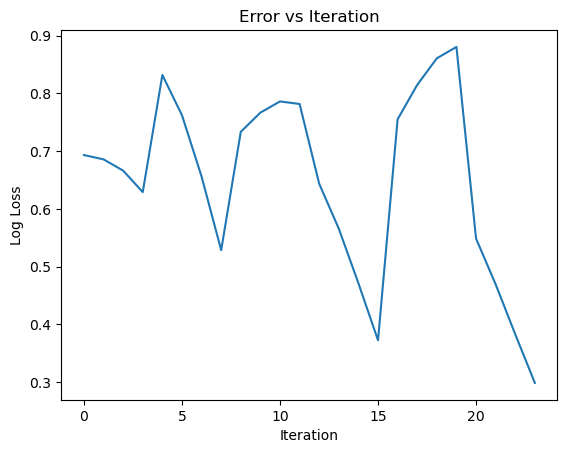

In [22]:
plt.plot(iterations, errors)

plt.xlabel("Iteration")
plt.ylabel("Log Loss")
plt.title("Error vs Iteration")

plt.show()

### Exercise 3

Consider the above dataset with two independent variables (X1 and X2) and<br> a dependent variable (Y).

| X1 | X2 | Y |
|---:|---:|---:|
| 4 | 1 | 1 |
| 2 | 8 | 0 |
| 1 | 0 | 1 |
| 3 | 2 | 0 |
| 1 | 4 | 0 |
| 6 | 7 | 0 |

Implement in Python how you can perform logistic regression using the two<br> independent variables (X1 and X2) to model the relationship with<br> the binary dependent variable.

In [23]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression

data = {
    "X1": [4, 2, 1, 3, 1, 6],
    "X2": [1, 8, 0, 2, 4, 7],
    "Y":  [2, -14, 1, -1, -7, -8]
}

df = pd.DataFrame(data)

# Positive Y -> 1, Negative Y -> 0
df["class"] = (df["Y"] > 0).astype(int)

print(df)

   X1  X2   Y  class
0   4   1   2      1
1   2   8 -14      0
2   1   0   1      1
3   3   2  -1      0
4   1   4  -7      0
5   6   7  -8      0


In [24]:
X = df[["X1", "X2"]].values
y = df["class"].values

model = LogisticRegression()

model.fit(X, y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


Coefficients: [[ 0.08482852 -0.94472563]]
Intercept: [1.3312031]


In [25]:
probabilities = model.predict_proba(X)[:, 1]
predictions = model.predict(X)

print("Actual classes:     ", y)
print("Predicted probability:", probabilities)
print("Predicted classes:   ", predictions)

Actual classes:      [1 0 1 0 0 0]
Predicted probability: [0.67388108 0.00233607 0.80471555 0.42463794 0.08604815 0.00838488]
Predicted classes:    [1 0 1 0 0 0]


In [26]:
accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 1.0
Accuracy (%): 100.0
